# 11 – Sensor Noise and Its Effect on Feedback

**Manufacturing context:** Real sensors (encoders, load cells, thermocouples) have measurement noise. This noise passes through the controller — especially the derivative term, which amplifies high-frequency content.

This notebook shows why derivative action is sensitive to noise and how it affects control effort.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
m = 1.0
c = 1.0
k = 4.0
ref = 1.0
t_end = 10.0
dt = 0.001

Kp = 30.0
Ki = 15.0
Kd = 8.0

noise_std = 0.01   # Measurement noise standard deviation [m]
seed = 42          # Random seed for reproducibility
# -----------------------------

In [2]:
np.random.seed(seed)
t = np.arange(0, t_end, dt)

def simulate_pid_noise(noise_std):
    n = len(t)
    x = np.zeros(n)        # true position
    v = np.zeros(n)        # velocity
    u = np.zeros(n)        # control effort
    y_meas = np.zeros(n)   # measured (noisy) position

    integral_e = 0.0
    prev_e = 0.0

    for i in range(1, n):
        # Sensor reading = true + noise
        y_meas[i-1] = x[i-1] + np.random.normal(0, noise_std)

        e = ref - y_meas[i-1]
        integral_e += e * dt
        derivative_e = (e - prev_e) / dt

        u[i] = Kp * e + Ki * integral_e + Kd * derivative_e
        prev_e = e

        a = (u[i] - c * v[i-1] - k * x[i-1]) / m
        v[i] = v[i-1] + a * dt
        x[i] = x[i-1] + v[i] * dt

    y_meas[-1] = x[-1] + np.random.normal(0, noise_std)
    return x, u, y_meas

np.random.seed(seed)
x_clean, u_clean, _ = simulate_pid_noise(0.0)
np.random.seed(seed)
x_noisy, u_noisy, y_meas = simulate_pid_noise(noise_std)

print(f"Noise std dev: {noise_std} m")
print(f"Control effort RMS (clean) : {np.sqrt(np.mean(u_clean**2)):.2f} N")
print(f"Control effort RMS (noisy) : {np.sqrt(np.mean(u_noisy**2)):.2f} N")

Noise std dev: 0.01 m
Control effort RMS (clean) : 80.47 N
Control effort RMS (noisy) : 140.13 N


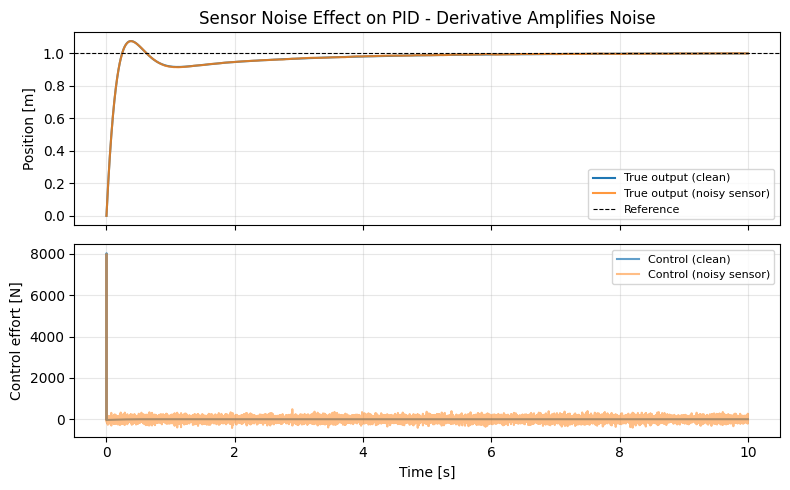

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t, x_clean, label="True output (clean)")
axes[0].plot(t, x_noisy, label="True output (noisy sensor)", alpha=0.8)
axes[0].axhline(ref, color="k", linestyle="--", linewidth=0.8, label="Reference")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("Sensor Noise Effect on PID - Derivative Amplifies Noise")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, u_clean, label="Control (clean)", alpha=0.7)
axes[1].plot(t, u_noisy, label="Control (noisy sensor)", alpha=0.5)
axes[1].set_ylabel("Control effort [N]")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Student Exercise

1. Increase `noise_std` to 0.05. How does the control effort change?
2. Set `Kd = 0` (remove derivative). How does noise affect the control signal now?
3. In practice, how do engineers deal with sensor noise in the derivative term? (Hint: low-pass filter.)